In [19]:
import os 
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

from tensorflow.keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()
print("train:", X_train.shape)
print("test:", X_test.shape)

train: (60000, 28, 28)
test: (10000, 28, 28)


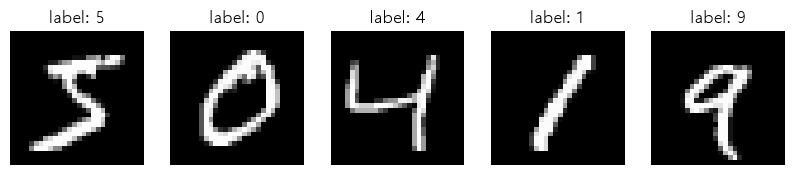

In [20]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'   # Windows 기본 한글 폰트
plt.rcParams['axes.unicode_minus'] = False       # 마이너스(-) 깨짐 방지


fig,axes = plt.subplots(1, 5, figsize=(10, 2))
for ax, img, label in zip(axes, X_train[:5], y_train[:5]):
    ax.imshow(img, cmap='grey')
    ax.set_title(f"label: {label}")
    ax.axis('off')
plt.show()

In [21]:
# 1. 정규화: 픽셀 0~255 → 0~1
# 2. 채널 차원 추가: (28,28) → (28, 28, 1)
X_train = X_train.reshape(-1, 28, 28, 1) / 255.0
X_test = X_test.reshape(-1, 28, 28, 1) / 255.0
print("변환 후:", X_train.shape)

변환 후: (60000, 28, 28, 1)


In [22]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential()
model.add(Input(shape=(28, 28, 1)))                  
model.add(Conv2D(32, (3, 3), activation='relu'))     
model.add(MaxPooling2D((2, 2)))                    
model.add(Conv2D(64, (3, 3), activation='relu'))     
model.add(MaxPooling2D((2, 2)))
model.add(Flatten())                             
model.add(Dense(64, activation='relu'))
model.add(Dense(10, activation='softmax'))           
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape          ┃      Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)             │ (None, 26, 26, 32)    │          320 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ max_pooling2d_3               │ (None, 13, 13, 32)    │            0 │
│ (MaxPooling2D)                │                       │              │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ conv2d_4 (Conv2D)             │ (None, 11, 11, 64)    │       18,496 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ max_pooling2d_4               │ (None, 5, 5, 64)      │            0 │
│ (MaxPooling2D)                │                       │              │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ flatten_2 (Flatten)           │ (None, 1600)          │            0 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ dense_4 (Dense)               │ (None, 64)            │      102,464 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ dense_5 (Dense)               │ (None, 10)            │          650 │
└───────────────────────────────┴───────────────────────┴──────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

In [24]:
history = model.fit(
    X_train, y_train,
    epochs=5,
    validation_split=0.2,
    verbose=1,
)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.9518 - loss: 0.1553 - val_accuracy: 0.9835 - val_loss: 0.0581
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.9844 - loss: 0.0495 - val_accuracy: 0.9864 - val_loss: 0.0458
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 31s 21ms/step - accuracy: 0.9890 - loss: 0.0355 - val_accuracy: 0.9833 - val_loss: 0.0564
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 25s 17ms/step - accuracy: 0.9922 - loss: 0.0246 - val_accuracy: 0.9858 - val_loss: 0.0519
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 22s 15ms/step - accuracy: 0.9928 - loss: 0.0200 - val_accuracy: 0.9856 - val_loss: 0.0497


In [25]:
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"테스트 정확도: {acc:.4f}")

테스트 정확도: 0.9872


313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


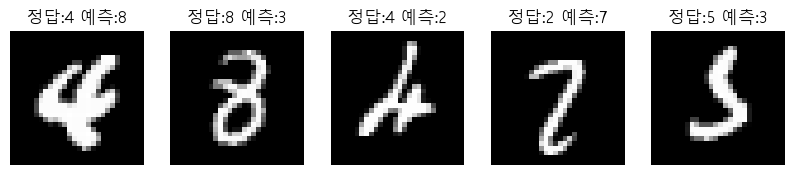

In [26]:
import numpy as np
pred = model.predict(X_test).argmax(axis=1)
wrong = np.where(pred != y_test)[0]
fig, axes = plt.subplots(1, 5, figsize=(10, 2))
for ax, idx in zip(axes, wrong[:5]):
    ax.imshow(X_test[idx].reshape(28,28), cmap='gray')
    ax.set_title(f"정답:{y_test[idx]} 예측:{pred[idx]}")
    ax.axis('off')
plt.show()